In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu


In [6]:
sentiment_path = "../Data/fear_greed_index.csv"
trades_path = "../Data/historical_data.csv"

sentiment = pd.read_csv(sentiment_path)
trades = pd.read_csv(trades_path)

In [7]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Cleaning the Sentiment file

In [9]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [10]:
sentiment.duplicated().sum()

np.int64(0)

In [13]:
sentiment.columns= sentiment.columns.str.strip().str.lower()
sentiment['date']=pd.to_datetime(sentiment['date'],errors='coerce')

In [28]:
sentiment["classification"] = sentiment["classification"].astype(str).str.strip().str.title()
sentiment["value"] = pd.to_numeric(sentiment["value"], errors="coerce")

In [29]:
def map_sentiment(x):
    if x in ["Fear", "Extreme Fear"]:
        return "Fear"
    elif x in ["Greed", "Extreme Greed"]:
        return "Greed"
    else:
        return "Neutral"

sentiment["sentiment_group"] = sentiment["classification"].apply(map_sentiment)

Cleaning thr trades file


In [15]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [16]:
trades.duplicated().sum()

np.int64(0)

In [23]:
trades.columns = trades.columns.str.strip()

In [24]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"],format="%d-%m-%Y %H:%M",errors="coerce")
trades["trade_date"] = trades["Timestamp IST"].dt.normalize()

In [25]:
numeric_cols = ["Execution Price", "Size Tokens", "Size USD","Start Position", "Closed PnL","Fee","Timestamp"]
for col in numeric_cols:
    trades[col] = pd.to_numeric(trades[col], errors="coerce")

In [26]:
trades["Side"] = trades["Side"].astype(str).str.strip().str.upper()
trades["Direction"] = trades["Direction"].astype(str).str.strip().str.title()

Now doing feature engineering

In [72]:
min_date = max(trades["trade_date"].min(), sentiment["date"].min())
max_date = min(trades["trade_date"].max(), sentiment["date"].max())
sentiment = sentiment[ (sentiment["date"] >= min_date) & (sentiment["date"] <= max_date)].copy()

trades = trades[(trades["trade_date"] >= min_date) & (trades["trade_date"] <= max_date)].copy()


In [30]:
trades["win_flag"] = (trades["Closed PnL"] > 0).astype(int)
trades["loss_flag"] = (trades["Closed PnL"] < 0).astype(int)
trades["abs_pnl"] = trades["Closed PnL"].abs()
trades["abs_size_usd"] = trades["Size USD"].abs()
trades["abs_size_tokens"] = trades["Size Tokens"].abs()

trades["long_flag"] = (trades["Side"] == "BUY").astype(int)
trades["short_flag"] = (trades["Side"] == "SELL").astype(int)

In [50]:
grp = trades.groupby(["Account", "trade_date"])

daily_trader = grp.agg({"Closed PnL": ["sum", "mean"], "Trade ID": "count",  "win_flag": "mean",  "abs_size_usd": ["mean", "median"],"abs_size_tokens": "mean","Fee": "sum","Start Position": "mean","long_flag": "mean", "short_flag": "mean"})
daily_trader.columns = [ "total_daily_pnl", "avg_pnl_per_trade", "trades_per_day", "win_rate", "avg_trade_size_usd", "median_trade_size_usd", "avg_trade_size_tokens", "total_fees","avg_start_position","long_ratio", "short_ratio"]

daily_trader = daily_trader.reset_index()

In [74]:
merged = daily_trader.merge(
    sentiment[["date", "classification", "sentiment_group", "value"]],
    left_on="trade_date",
    right_on="date",
    how="left"
)

In [76]:
summary_by_sentiment = fg.groupby("sentiment_group").agg(
    trader_days=("trade_date", "count"),
    mean_daily_pnl=("total_daily_pnl", "mean"),
    median_daily_pnl=("total_daily_pnl", "median"),
    mean_win_rate=("win_rate", "mean"),
    mean_trades_per_day=("trades_per_day", "mean"),
    mean_trade_size_usd=("avg_trade_size_usd", "mean"),
    mean_total_fees=("total_fees", "mean"),
    mean_start_position=("avg_start_position", "mean"),
    mean_long_ratio=("long_ratio", "mean"),
    mean_short_ratio=("short_ratio", "mean")
).reset_index()

display(summary_by_sentiment)

,sentiment_group,trader_days,mean_daily_pnl,median_daily_pnl,mean_win_rate,mean_trades_per_day,mean_trade_size_usd,mean_total_fees,mean_start_position,mean_long_ratio,mean_short_ratio
0,Fear,790,5185.146443,122.737038,0.357071,105.363291,8529.859802,147.272889,1022.889217,0.521512,0.478488
1,Greed,1174,4144.208334,265.247725,0.362748,76.912266,5954.632633,76.771173,-127.455235,0.472276,0.527724


In [77]:
fear_pnl = fg.loc[fg["sentiment_group"] == "Fear", "total_daily_pnl"].dropna()
greed_pnl = fg.loc[fg["sentiment_group"] == "Greed", "total_daily_pnl"].dropna()


In [83]:
trader_profile = fg.groupby("Account").agg(
    total_pnl=("total_daily_pnl", "sum"),
    avg_daily_pnl=("total_daily_pnl", "mean"),
    pnl_std=("total_daily_pnl", "std"),
    avg_win_rate=("win_rate", "mean"),
    avg_trades_per_day=("trades_per_day", "mean"),
    avg_trade_size_usd=("avg_trade_size_usd", "mean")
).reset_index()

trader_profile["size_segment"] = np.where(
    trader_profile["avg_trade_size_usd"] >= trader_profile["avg_trade_size_usd"].median(),
    "Large Traders",
    "Small Traders"
)
trader_profile["activity_segment"] = np.where(
    trader_profile["avg_trades_per_day"] >= trader_profile["avg_trades_per_day"].median(),
    "Frequent Traders",
    "Infrequent Traders"
)
trader_profile["consistency_segment"] = np.where(
    trader_profile["avg_win_rate"] >= trader_profile["avg_win_rate"].median(),
    "Consistent Traders",
    "Inconsistent Traders"
)

trader_profile.head()

,Account,total_pnl,avg_daily_pnl,pnl_std,avg_win_rate,avg_trades_per_day,avg_trade_size_usd,size_segment,activity_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.474580e+06,77609.458065,167976.009961,0.306472,178.789474,27762.857389,Large Traders,Frequent Traders,Inconsistent Traders
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,5.981840e+04,1272.731928,3194.021987,0.408579,139.574468,4610.545874,Small Traders,Frequent Traders,Consistent Traders
2,0x271b280974205ca63b716753467d5a371de622ab,-5.139785e+04,-5139.785076,36625.743382,0.455943,321.000000,11850.433006,Large Traders,Frequent Traders,Consistent Traders
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.269591e+05,926.708505,3242.006543,0.445986,90.686131,460.159202,Small Traders,Frequent Traders,Consistent Traders
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.263652e+05,2071.560031,3977.387867,0.490109,36.459016,2486.135215,Small Traders,Infrequent Traders,Consistent Traders


In [84]:
fg = fg.merge(
    trader_profile[["Account", "size_segment", "activity_segment", "consistency_segment"]],
    on="Account",
    how="left"
)

In [85]:
segment_summary = fg.groupby(["sentiment_group", "size_segment"]).agg(
    mean_pnl=("total_daily_pnl", "mean"),
    mean_win_rate=("win_rate", "mean"),
    mean_trades=("trades_per_day", "mean"),
    mean_trade_size=("avg_trade_size_usd", "mean")
).reset_index()

display(segment_summary)

,sentiment_group,size_segment,mean_pnl,mean_win_rate,mean_trades,mean_trade_size
0,Fear,Large Traders,9540.175136,0.357213,94.402027,19262.220995
1,Fear,Small Traders,2575.655567,0.356986,111.931174,2099.133258
2,Greed,Large Traders,3347.140958,0.271914,41.356295,12202.799882
3,Greed,Small Traders,4589.846268,0.413533,96.791501,2461.301408


In [86]:
drawdown_df = fg.sort_values(["Account", "trade_date"]).copy()

drawdown_df["cum_pnl"] = drawdown_df.groupby("Account")["total_daily_pnl"].cumsum()
drawdown_df["running_peak"] = drawdown_df.groupby("Account")["cum_pnl"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum_pnl"] - drawdown_df["running_peak"]

drawdown_summary = drawdown_df.groupby("sentiment_group").agg(avg_drawdown=("drawdown", "mean"),worst_drawdown=("drawdown", "min")).reset_index()
display(drawdown_summary)

,sentiment_group,avg_drawdown,worst_drawdown
0,Fear,-9414.586961,-113383.715290
1,Greed,-10557.918320,-369393.229261


Charts

<Figure size 1000x500 with 0 Axes>

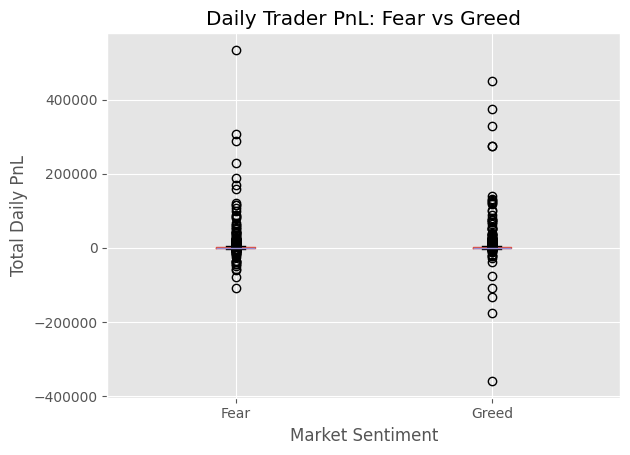

In [69]:
plt.figure(figsize=(10, 5))

fg.boxplot(column="total_daily_pnl", by="sentiment_group")

plt.title("Daily Trader PnL: Fear vs Greed")
plt.suptitle("") 
plt.xlabel("Market Sentiment")
plt.ylabel("Total Daily PnL")
plt.tight_layout()
plt.savefig("../Charts/fear_vs_greed_boxplot.png")
plt.show()

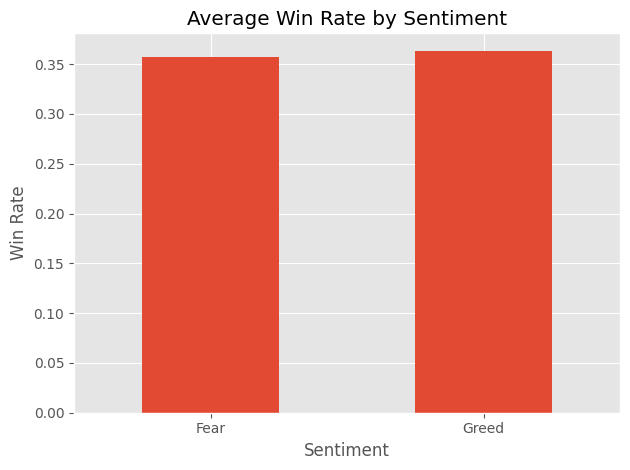

In [68]:
win_rate = fg.groupby("sentiment_group")["win_rate"].mean()

plt.figure()
win_rate.plot(kind="bar")
plt.title("Average Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Charts/avg_winRate_By_Sentiment.png")
plt.show()

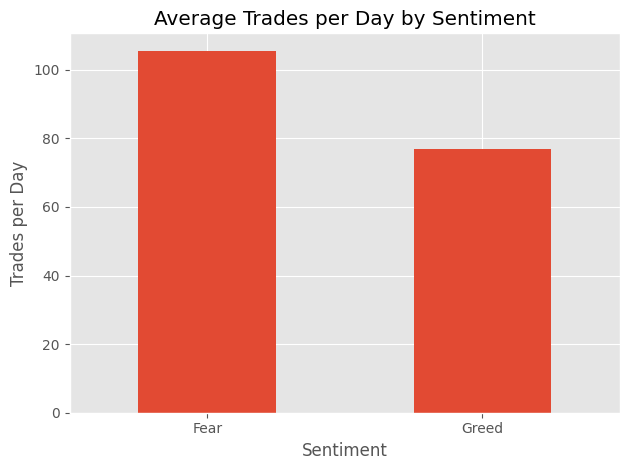

In [67]:
trades_day = fg.groupby("sentiment_group")["trades_per_day"].mean()

plt.figure()
trades_day.plot(kind="bar")

plt.title("Average Trades per Day by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trades per Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Charts/avg_trades_per_day_by_Sentiment.png")
plt.show()

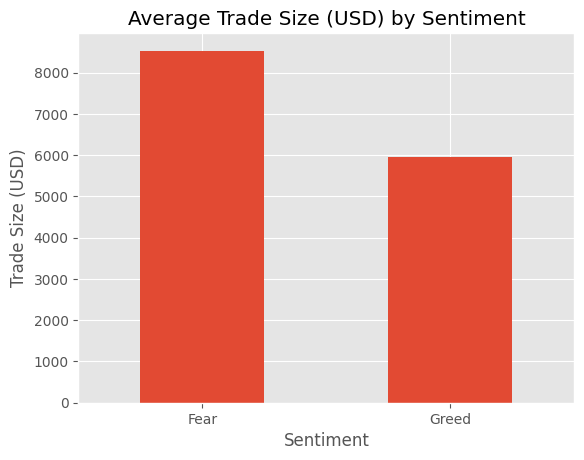

In [65]:
size_usd = fg.groupby("sentiment_group")["avg_trade_size_usd"].mean()

plt.figure()
size_usd.plot(kind="bar")

plt.title("Average Trade Size (USD) by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Size (USD)")
plt.xticks(rotation=0)
plt.savefig("../Charts/Trade_size_Sentiment.png")
plt.show()

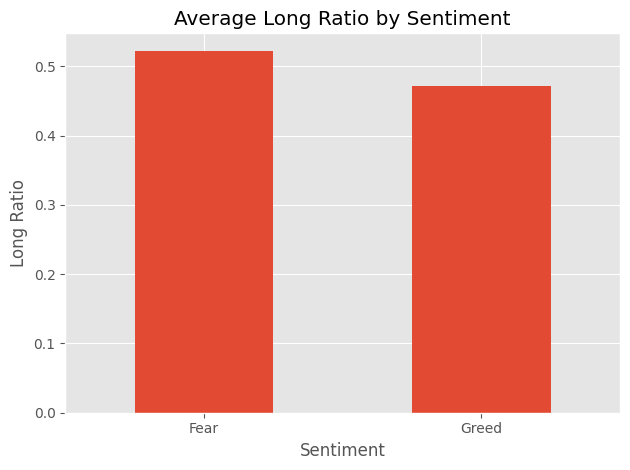

In [66]:
long_ratio = fg.groupby("sentiment_group")["long_ratio"].mean()

plt.figure()
long_ratio.plot(kind="bar")

plt.title("Average Long Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Long Ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Charts/avg_ratio_sentiment.png")
plt.show()

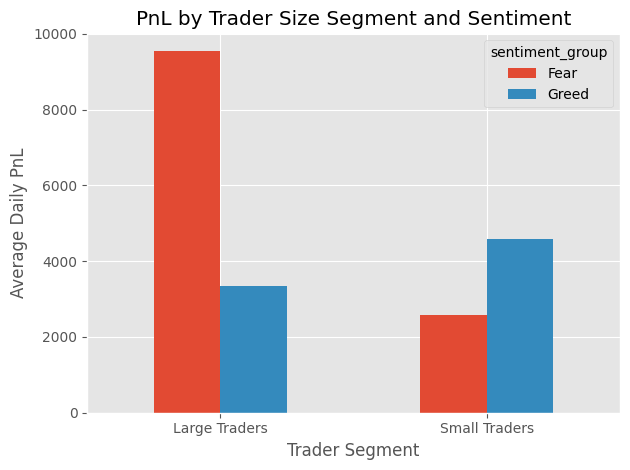

In [63]:
pivot1 = fg.pivot_table( index="size_segment",columns="sentiment_group",values="total_daily_pnl",aggfunc="mean")
pivot1.plot(kind="bar")
plt.title("PnL by Trader Size Segment and Sentiment")
plt.xlabel("Trader Segment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Charts/Pnl_By_TraderSizeSegent_And_Sentiment.png")
plt.show()

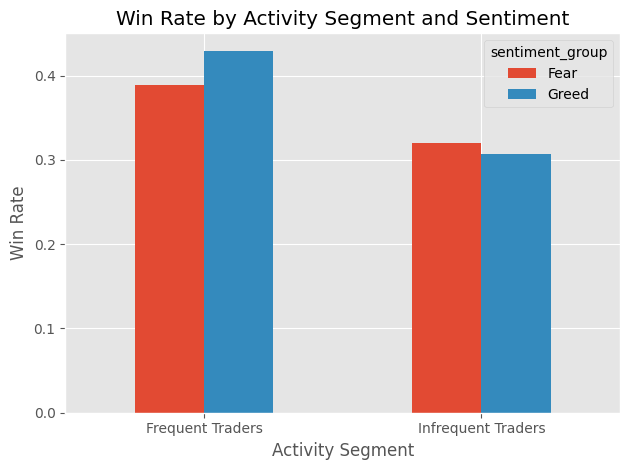

In [62]:
pivot2 = fg.pivot_table(
    index="activity_segment",
    columns="sentiment_group",
    values="win_rate",
    aggfunc="mean"
)

pivot2.plot(kind="bar")
plt.title("Win Rate by Activity Segment and Sentiment")
plt.xlabel("Activity Segment")
plt.ylabel("Win Rate")
plt.style.use("ggplot")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Charts/winRate_By_Activity_And_Sentiment.png")
plt.show()

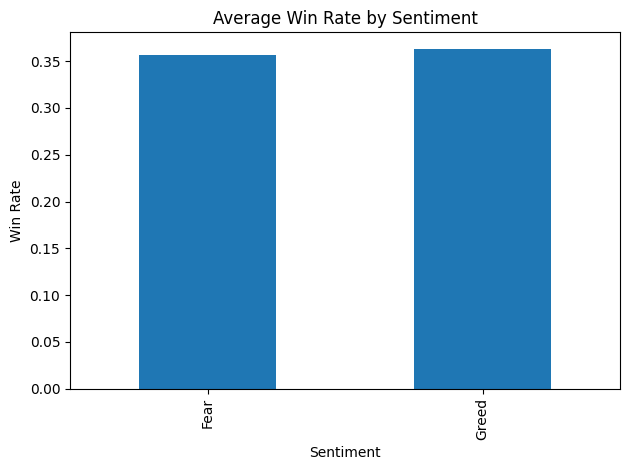

In [57]:
plt.figure()
win_rate.plot(kind="bar")

plt.title("Average Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")

plt.tight_layout()
plt.style.use("ggplot")
plt.savefig("../Charts/winrate.png")
plt.show()

In [87]:
summary_by_sentiment.to_csv("../outputs/summary_by_sentiment.csv", index=False)
segment_summary.to_csv("../outputs/segment_summary.csv", index=False)
drawdown_summary.to_csv("../outputs/drawdown_summary.csv", index=False)
trader_profile.to_csv("../outputs/trader_profile_segments.csv", index=False)

print("Tables saved successfully.")

Tables saved successfully.


## Actionable Strategy Recommendations

### Rule 1: Adjust Position Size Based on Sentiment

During Fear periods, traders should reduce position size and tighten risk exposure, especially for segments that show weaker performance or higher drawdowns.

Rationale:
Fear conditions are associated with increased downside risk, so controlling exposure helps preserve capital.



### Rule 2: Monitor Directional Bias

During strong Greed phases, monitor long bias closely. If traders become overly long, introduce position limits or reduce exposure.

Rationale:
Excessive directional bias can increase risk during sudden reversals.

Simple Model (BONUS)

In [88]:

fg = fg.sort_values(["Account", "trade_date"])
fg["next_day_pnl"] = fg.groupby("Account")["total_daily_pnl"].shift(-1)

#  classification target
def classify_pnl(x):
    if x > 0:
        return "Profit"
    elif x < 0:
        return "Loss"
    else:
        return "Neutral"

fg["target"] = fg["next_day_pnl"].apply(classify_pnl)

# drop last rows where next_day_pnl is NaN
model_df = fg.dropna(subset=["target"]).copy()

model_df["target"].value_counts()

target
Profit     1221
Neutral     562
Loss        181
Name: count, dtype: int64

In [89]:
features = [ "win_rate", "trades_per_day", "avg_trade_size_usd", "long_ratio","short_ratio"]

X = model_df[features]
y = model_df["target"]

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# train-test split THE DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# model 
model = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.09      0.03      0.04        37
           1       0.38      0.27      0.31       112
           2       0.66      0.82      0.73       244

    accuracy                           0.59       393
   macro avg       0.37      0.37      0.36       393
weighted avg       0.52      0.59      0.55       393



In [92]:
from sklearn.metrics import confusion_matrix,accuracy_score

cm = confusion_matrix(y_test, y_pred)
accu=accuracy_score(y_test, y_pred)
print('accuracy_score:')
print(accu)

print("Confusion Matrix:")
print(cm)

accuracy_score:
0.5852417302798982
Confusion Matrix:
[[  1  10  26]
 [  5  30  77]
 [  5  40 199]]


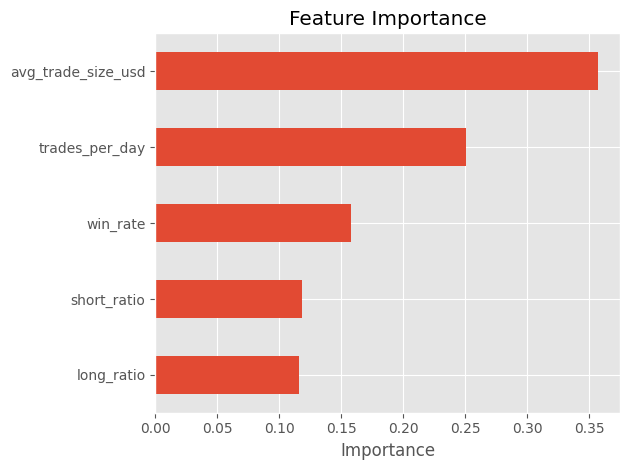

In [94]:
# i just added the feature importance for better analysis just for basic understanding only 
importance = pd.Series(model.feature_importances_, index=X.columns)
plt.figure()
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()